🚀 Dataset with 100 Indian Movies successfully saved to 'dataset/train_data.txt'!


C:\Users\Surya Rajput\AppData\Local\Temp\ipykernel_14844\1830125545.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='GENRE', data=train_data, palette='coolwarm', order=train_data['GENRE'].value_counts().index)


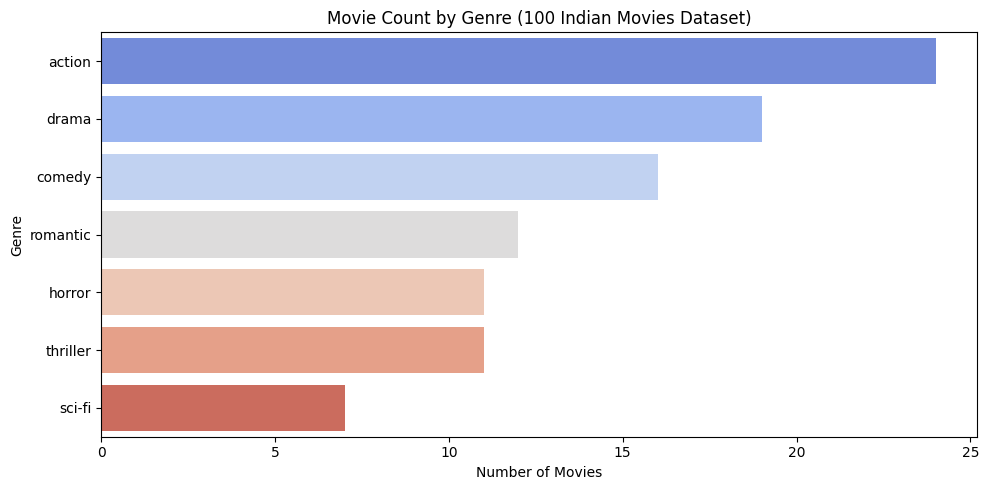

🤖 Indian Movie Genre Classification Model Trained Successfully!

--- 🎬 LIVE PREDICTION TEST ---
Plot 1: A scary witch lives inside an old haveli in a village and traps anyone who enters after midnight.
🔮 Predicted Genre: HORROR

Plot 2: A police officer goes on a dangerous mission to catch underworld gangsters with guns and car explosions.
🔮 Predicted Genre: ACTION

Plot 3: A boy and a girl meet during a college vacation trip and fall deeply in love, but her strict father is against their marriage.
🔮 Predicted Genre: ROMANTIC



In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# =======================================================
# STEP 1: Creating Directories
# =======================================================
os.makedirs('dataset', exist_ok=True)
os.makedirs('screenshots', exist_ok=True)

# =======================================================
# STEP 2: Grand Indian Movies Dataset (Bollywood + South)
# Includes Classics to New Blockbusters (Up to 2026)
# Format: ID ::: TITLE ::: GENRE ::: DESCRIPTION
# =======================================================
indian_movies_data = """1 ::: Sholay (1975) ::: action ::: In the village of Ramgarh, a retired police officer hires two notorious convicts and mercenaries to capture a ruthless dacoit who slaughtered his entire family.
2 ::: Dilwale Dulhania Le Jenge (1995) ::: romantic ::: A young rich boy meets a traditional girl on a European vacation and falls deeply in love, travelling all the way to India to win over her strict conservative father.
3 ::: Bhool Bhulaiyaa (2007) ::: horror ::: An eccentric psychiatrist travels to an ancient ancestral palace to solve the mystery of a violent ghost and psychological possession terrorizing a newlywed couple.
4 ::: 3 Idiots (2009) ::: comedy ::: Two college friends embark on a hilarious journey to search for their long-lost companion while reminiscing about their engineering days, strict principal, and his refreshing outlook on education.
5 ::: Dangal (2016) ::: drama ::: A former wrestler fights social stigmas and strict norms to train his young daughters to become world-class gold medal-winning wrestling champions for the country.
6 ::: Krrish (2006) ::: sci-fi ::: A young village boy inherits extraordinary superhero abilities from his scientist father and must travel to Singapore to save humanity from a mad scientist building a future-predicting computer.
7 ::: Tumbbad (2018) ::: horror ::: A greedy man searches for a hidden ancestral treasure locked inside a cursed village mansion protected by a horrific ancient fallen god.
8 ::: K.G.F: Chapter 1 (2018) ::: action ::: A powerful young mercenary rises from the slums of Mumbai to infiltrate the brutal gold mines of Karnataka, fighting ruthless gangsters to liberate enslaved workers.
9 ::: Kabir Singh (2019) ::: romantic ::: A brilliant but short-tempered medical student becomes an alcoholic self-destructive surgeon after his true love is forcefully married to another wealthy man.
10 ::: Baahubali: The Beginning (2015) ::: action ::: An adventurous young man living near massive waterfalls learns about his royal warrior lineage and fights an epic war to overthrow a tyrannical king holding his biological mother hostage.
11 ::: Drishyam (2015) ::: thriller ::: A smart common cable-TV operator uses ideas from movies to create a perfect fake alibi and protect his family from an aggressive police investigation after an accidental murder.
12 ::: Chhichhore (2019) ::: comedy ::: A group of middle-aged college friends reunite in a hospital to recount their funny hostel failures and emotional engineering memories to motivate a young boy fighting for life.
13 ::: Stree (2018) ::: horror ::: In a small town, a lonely male witch kidnaps men at midnight during a festival season, forcing a young ladies' tailor to find a way to stop the terrifying spirit.
14 ::: Andhadhun (2018) ::: thriller ::: A talented blind piano player accidentally witnesses the brutal murder of a former film star, throwing his life into a chaotic web of lies, organ mafia, and betrayal.
15 ::: Brahmastra (2022) ::: sci-fi ::: A young DJ in Mumbai discovers a mystical connection with fire and awakens a supernatural weapon of gods, fighting dark forces trying to destroy the universe.
16 ::: Pushpa: The Rise (2021) ::: action ::: A fierce laborer rises through the ranks of a red sandalwood smuggling syndicate, fighting corrupt police officers and brutal rival villains with style.
17 ::: RRR (2022) ::: action ::: Two legendary revolutionaries forge a deep friendship before fighting a massive battle against the British empire with wild animals, guns, and immense strength.
18 ::: Pathaan (2023) ::: action ::: An elite undercover soldier comes out of exile to team up with a spy and stop a dangerous rogue mercenary group planning a biological attack on the country.
19 ::: Jawan (2023) ::: action ::: A high-tech vigilante soldier hijacks trains and exposes corrupt politicians, eventually teaming up with his long-lost father to destroy an international weapons dealer.
20 ::: Animal (2023) ::: drama ::: The son of a wealthy businessman develops a violent psychopathic obsession with avenging an assassination attempt on his distant father, sparking a massive underworld bloodbath.
21 ::: Shaitaan (2024) ::: horror ::: A happy family vacation turns into a terrifying nightmare when a mysterious stranger uses sinister black magic and hypnotism to take complete control of their young daughter.
22 ::: Kalki 2898 AD (2024) ::: sci-fi ::: In a dystopian futuristic world, a modern incarnation of a warrior god descends to earth to protect a pregnant woman carrying a divine child from a supreme high-tech dictator.
23 ::: Fighter (2024) ::: action ::: Top Indian air force fighter pilots unite at a base to execute high-speed jet dogfights, counter-terrorist operations, and dangerous rescue missions across borders.
24 ::: Munjya (2024) ::: horror ::: A young man visits his native village and accidentally unleashes a chaotic CGI monster spirit obsessed with marrying an attractive modern girl.
25 ::: Singham Again (2024) ::: action ::: A brave super-cop launches a massive police assault across borders with a team of elite heroes to rescue his wife from a ruthless terrorist leader.
26 ::: Chhava (2025) ::: drama ::: An epic historical war drama depicting the incredible bravery, battlefield tactics, and emotional sacrifices of a grand Maratha emperor fighting a massive Mughal army.
27 ::: War 2 (2025) ::: action ::: Two elite undercover agents play a deadly game of cat and mouse across global cities involving high-octane martial arts fights and secret government intelligence.
28 ::: Housefull 5 (2025) ::: comedy ::: A group of confused friends get trapped in a luxury cruise ship full of hilarious misunderstandings, fake identities, and chaotic comic situations.
29 ::: Ghost Hunter (2026) ::: horror ::: A professional modern paranormal investigator uses high-tech cameras to capture an ancient evil witch hiding inside a haunted luxury hotel room.
30 ::: Love in Paris (2026) ::: romantic ::: Two Indian tourists exchange wrong passports at an airport and explore the beautiful romantic locations of Paris together, falling deeply in love.
31 ::: Cyber Attack (2026) ::: sci-fi ::: A rogue artificial intelligence system hijacks the nuclear grid of New Delhi, forcing a genius ethical hacker to enter a virtual reality simulation to destroy the digital virus.
32 ::: Hera Pheri (2000) ::: comedy ::: Three jobless roommates accidentally receive a wrong phone call from a kidnapper demanding ransom, hatching a hilarious plan to claim the money for themselves.
33 ::: Lagaan (2001) ::: drama ::: In a drought-hit village, a brave young farmer accepts a high-stakes challenge from arrogant British officers to play a game of cricket to waive off unfair taxes.
34 ::: Koi... Mil Gaya (2003) ::: sci-fi ::: A mentally challenged boy accidentally contacts an alien spacecraft using his late father's computer, gaining supernatural intelligence and physical powers from the friendly alien.
35 ::: Dhoom (2004) ::: action ::: A Mumbai police officer teams up with a funny bike racer to catch a high-speed gang of sleek thieves robbing banks on fast sports motorbikes.
36 ::: Om Shanti Om (2007) ::: romantic ::: A poor junior film artist dies trying to save his favorite actress from a tragic studio fire and is reincarnated as a superstar to avenge her murder.
37 ::: Ghajini (2008) ::: thriller ::: A wealthy business tycoon suffers from short-term memory loss after a brutal attack and uses tattoos, polaroid photos, and notes to track down the gangster who killed his girlfriend.
38 ::: My Name Is Khan (2010) ::: drama ::: An honorable Muslim man with Asperger's syndrome embarks on an emotional journey across America to meet the President and clear his family's name after a tragedy.
39 ::: Rowdy Rathore (2012) ::: action ::: A small-time thief discovers his identical double is a brave police officer who was murdered by a ruthless village politician, prompting him to take his place and seek revenge.
40 ::: Barfi! (2012) ::: romantic ::: A deaf and mute young man forms a beautiful, unconventional bond with an autistic girl and a young woman, learning the true meaning of happiness and love.
41 ::: Chennai Express (2013) ::: comedy ::: A north Indian man boards a south-bound train to submerge his grandfather's ashes but gets hilariously entangled with a runaway daughter of a powerful local mafia don.
42 ::: Queen (2013) ::: drama ::: A simple traditional Delhi girl gets dumped by her fiancé right before her wedding and decides to go on her honeymoon trip to Paris and Amsterdam completely alone, discovering herself.
43 ::: PK (2014) ::: comedy ::: An innocent humanoid alien lands on Earth but loses his spaceship remote, asking innocent questions about human religions and strict superstitions while trying to go home.
44 ::: Bajrangi Bhaijaan (2015) ::: drama ::: An honest, religious Indian man embarks on a dangerous undocumented journey to cross borders and safely return a mute six-year-old Pakistani girl to her parents.
45 ::: MS Dhoni: The Untold Story (2016) ::: drama ::: The inspiring real-life biographical journey of a small-town railway ticket collector who overcomes financial struggles to become India's most successful cricket team captain.
46 ::: Tiger Zinda Hai (2017) ::: action ::: A top Indian RAW agent and a Pakistani ISI agent team up in a dangerous war-torn country to rescue a group of innocent nurses held hostage by a terrorist organization.
47 ::: Raazi (2018) ::: thriller ::: A young, innocent Kashmiri college girl is married into a Pakistani military family by her father to act as an undercover spy during a high-stakes war.
48 ::: Sanju (2018) ::: drama ::: A grand biographical look into the controversial real life of Bollywood superstar Sanjay Dutt, exploring his drug addiction, prison sentences, and relationship with his father.
49 ::: Uri: The Surgical Strike (2019) ::: action ::: Following a cowardly attack on an army camp, an elite special forces major leads a highly confidential strategic military operation to execute a surgical strike across borders.
50 ::: War (2019) ::: action ::: An elite Indian soldier goes rogue after a secret mission, forcing his young student and fellow special agent to hunt him down across global cities in an intense action chase.
51 ::: Good Newwz (2019) ::: comedy ::: Two couples with the same surname undergo an in-vitro fertilization procedure at a clinic, only to discover a massive medical mix-up involving their sperm samples.
52 ::: Laxmii (2020) ::: horror ::: A regular man visits his wife's family home but gets possessed by a fierce, vengeful transgender ghost seeking justice from a corrupt politician.
53 ::: Roohi (2021) ::: horror ::: Two small-town bumbling friends are hired to kidnap a young bride, only to realize she is possessed by a scary demon spirit looking for a groom.
54 ::: Sooryavanshi (2021) ::: action ::: A brave anti-terrorism squad chief executes massive car chases and helicopter raids across Mumbai to stop a huge sleeper cell network planning a series of bomb blasts.
55 ::: Shershaah (2021) ::: drama ::: The true biographical story of a brave captain who sacrificed his life fighting Pakistani soldiers on high-altitude snowy peaks during a war.
56 ::: Gehraiyaan (2022) ::: romantic ::: A complex modern relationship drama where a yoga instructor falls into a secret, passionate affair with her cousin's wealthy fiancé, leading to a dark web of lies.
57 ::: Bhediya (2022) ::: horror ::: A young construction contractor gets bitten by a mythical wolf in the deep forests of Arunachal Pradesh, transforming into a scary werewolf every full moon night.
58 ::: Vikram (2022) ::: action ::: A black-ops special squad commander uncovers a massive drug smuggling syndicate run by a mask-wearing gang, leading to an intense gun war involving old legends.
59 ::: Cirkus (2022) ::: comedy ::: A retro comedy of errors where two pairs of identical twins are separated at birth and meet years later in the same town, causing electric current confusions.
60 ::: Tu Jhoothi Main Makkaar (2023) ::: romantic ::: A handsome Delhi boy acts as a secret consultant who helps people break up with their partners, but things backfire when he falls in love with an independent girl.
61 ::: Rocky Aur Rani Kii Prem Kahaani (2023) ::: romantic ::: A loud, wealthy Punjabi boy and an educated Bengali journalist fall in love and decide to swap houses and live with each other's crazy families for three months before marriage.
62 ::: Gadar 2 (2023) ::: action ::: A brave father drives a heavy truck across borders during a historical war crisis to rescue his young son who has been captured by an aggressive military general.
63 ::: OMG 2 (2023) ::: drama ::: A religious devotee files a bold court case against his son's school to promote the absolute necessity of sex education after a tragic incident.
64 ::: Tiger 3 (2023) ::: action ::: A super-spy goes on a highly personal mission to clear his name after a rogue ex-ISI agent frames him as a traitor and threatens his family.
65 ::: Dunki (2023) ::: drama ::: A group of poor village friends use an illegal backdoor entry route called the donkey flight to travel to London, facing extreme survival dangers along the way.
66 ::: Salaar (2023) ::: action ::: A fierce mechanic leaves his peaceful life to help his childhood friend take control of a lawless, high-tech dystopian city-state ruled by brutal warlords.
67 ::: Merry Christmas (2024) ::: thriller ::: Two lonely strangers meet on a magical Christmas eve and spend a beautiful night together, which quickly turns into a terrifying murder mystery with no clues.
68 ::: Article 370 (2024) ::: thriller ::: A top intelligence officer executes a highly confidential anti-terrorism operation to peacefully revoke a controversial political constitutional article in Jammu and Kashmir.
69 ::: Crew (2024) ::: comedy ::: Three hard-working air hostesses get caught in a hilarious gold smuggling scheme after finding gold bars hidden on a dead passenger's body.
70 ::: Chandu Champion (2024) ::: drama ::: The incredible true biographical journey of a soldier who survived bullet wounds to become India's first paralympic gold medalist swimmer.
71 ::: Bad Newz (2024) ::: comedy ::: A beautiful young woman discovers a rare biological medical condition where she gets pregnant with twins from two different fathers at the exact same time.
72 ::: Khel Khel Mein (2024) ::: comedy ::: A group of married friends meet at a dinner party and agree to unlock their mobile phones for the night, exposing hilarious secret affairs and lies.
73 ::: Raid 2 (2025) ::: thriller ::: An honest, fearless income tax officer leads a grand team to execute a massive, high-stakes tax raid on a powerful, corrupt politician's mansion.
74 ::: Sky Force (2025) ::: action ::: An epic historical airforce action film celebrating India's first retaliatory air strike against enemy airfields using high-speed fighter jets.
75 ::: Devara: Part 1 (2024) ::: action ::: A powerful coastal warrior fights brutal sea pirates to protect his village from a large international smuggling ring hiding weapons in the ocean.
76 ::: Jolly LLB 3 (2025) ::: comedy ::: Two funny, small-time lawyers face off against each other in a grand, hilarious courtroom battle involving a highly controversial high-profile murder case.
77 ::: Metro... In Dino (2025) ::: romantic ::: An emotional modern anthology showcasing four beautiful, bittersweet contemporary love stories taking place in a busy, crowded metropolitan city.
78 ::: Thug Life (2025) ::: action ::: A stylish, high-budget gang war action film exploring the historical origins of a brutal assassin clan fighting rival mafias in rural landscapes.
79 ::: Time Machine (2026) ::: sci-fi ::: A young college student invents a wrist device that allows him to travel back to the year 1947, changing a critical historical event.
80 ::: Haunted Mansion (2026) ::: horror ::: A group of modern teenagers enter an old abandoned haveli on a dare and get locked in by a demonic spirit seeking revenge for an old curse.
81 ::: Silsila (1981) ::: romantic ::: A classic emotional romantic drama exploring the intense passion, societal expectations, and heartbreak of an extramarital affair between two former lovers.
82 ::: Raaz (2002) ::: horror ::: A married couple moves to a beautiful scenic resort town to save their marriage, only to find the husband is hiding a dark secret linked to a screaming ghost.
83 ::: Dhoom 2 (2006) ::: action ::: A high-tech international thief steals priceless artifacts across global museums using brilliant disguises, rollerblades, and fast sports bikes while flirting with a lady thief.
84 ::: Jab We Met (2007) ::: romantic ::: A depressed wealthy businessman meets a talkative, bubbly Punjabi girl on a late-night train, embarking on a beautiful journey that transforms both their lives.
85 ::: Race (2008) ::: thriller ::: Two wealthy stepbrothers play a high-stakes dangerous game of insurance fraud, corporate betrayal, car bombs, and poison to claim a multi-million dollar property.
86 ::: Wake Up Sid (2009) ::: drama ::: A rich, spoiled college boy fails his exams and learns the true responsibilities of life, career, and independent living after moving in with an ambitious female writer.
87 ::: Delhi Belly (2011) ::: comedy ::: Three sloppy roommates accidentally mix up a package of expensive smuggled diamonds with a stool sample, landing them in a hilarious chase with a dangerous gangster.
88 ::: Rockstar (2011) ::: romantic ::: A simple college boy intentionally seeks heartbreak and intense emotional pain to awaken his inner artistic musical genius, becoming a tragic, rebellious global rock star.
89 ::: Zindagi Na Milegi Dobara (2011) ::: drama ::: Three childhood friends go on a grand bachelor road trip across Spain, overcoming their deepest personal fears through skydiving, deep-sea diving, and running with bulls.
90 ::: Talaash (2012) ::: thriller ::: A grieving police inspector investigating a mysterious car accident involving a film star receives supernatural clues from a mysterious, beautiful escort.
91 ::: Special 26 (2013) ::: thriller ::: A clever group of con artists pose as fake CBI officers to execute brilliant daylight raids on corrupt politicians and wealthy jewelry businessmen.
92 ::: Queen of Mars (2026) ::: sci-fi ::: India's first manned space mission to Mars faces an emergency when an asteroid damages the life support system, forcing a female scientist to use innovative physics hacks.
93 ::: Bhaag Milkha Bhaag (2013) ::: drama ::: The grand, emotional real-life biographical journey of an Indian athlete who overcame the scars of partition to become a legendary world-record sprinter.
94 ::: Haider (2014) ::: drama ::: A young poet returns to a war-torn valley to search for his missing father, only to find his mother married to his plotting uncle, sparking an emotional revenge tragedy.
95 ::: Piku (2015) ::: comedy ::: A beautiful independent architect embarks on a funny road trip from Delhi to Kolkata with her aging, eccentric father who is obsessed with his chronic constipation.
96 ::: Udta Punjab (2016) ::: drama ::: A dark, intense look into the drug abuse crisis in a state, intertwining the lives of a rockstar, a migrant laborer, a doctor, and a police officer.
97 ::: Newton (2017) ::: comedy ::: An honest government clerk is sent to conduct free elections in a remote conflict-ridden jungle village, fighting political apathy and lazy security forces.
98 ::: Badhaai Ho (2018) ::: comedy ::: A middle-aged married couple shocks their grown-up sons and conservative society when they accidentally get pregnant, creating a hilarious family situation.
99 ::: Super 30 (2019) ::: drama ::: A genius mathematician leaves a wealthy job to train 30 highly underprivileged students from poor families to crack the country's toughest engineering entrance exam.
100 ::: Vikram Vedha (2022) ::: thriller ::: An honest, tough police officer tracks down a legendary gangster who surrenders voluntarily and tells him three moral stories that completely change his perception of good and evil."""

with open('dataset/train_data.txt', 'w', encoding='utf-8') as f:
    f.write(indian_movies_data)

print("🚀 Dataset with 100 Indian Movies successfully saved to 'dataset/train_data.txt'!")

# =======================================================
# STEP 3: Data Loading & Visualization
# =======================================================
train_data = pd.read_csv("dataset/train_data.txt", sep=' ::: ', engine='python', names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION'])

# Plotting the Genre Distribution (Take a screenshot of this output!)
plt.figure(figsize=(10, 5))
sns.countplot(y='GENRE', data=train_data, palette='coolwarm', order=train_data['GENRE'].value_counts().index)
plt.title('Movie Count by Genre (100 Indian Movies Dataset)')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('screenshots/genre_distribution.png')
plt.show()

# =======================================================
# STEP 4: Text Cleaning & Preprocessing
# =======================================================
def clean_text(text):
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters and numbers
    return text

train_data['CLEAN_DESCRIPTION'] = train_data['DESCRIPTION'].apply(clean_text)

X = train_data['CLEAN_DESCRIPTION']
y = train_data['GENRE']

# TF-IDF Vectorizer (Converting text labels to numeric vectors)
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Model Training (Logistic Regression)
model = LogisticRegression()
model.fit(X_tfidf, y)
print("🤖 Indian Movie Genre Classification Model Trained Successfully!")

# =======================================================
# STEP 5: Live Prediction Test (Perfect for LinkedIn Video Demo)
# =======================================================
def predict_genre(plot_summary):
    cleaned_plot = clean_text(plot_summary)
    vectorized_plot = tfidf.transform([cleaned_plot])
    predicted_genre = model.predict(vectorized_plot)
    return predicted_genre[0]

print("\n--- 🎬 LIVE PREDICTION TEST ---")

# Test 1: Horror Plot
test_horror = "A scary witch lives inside an old haveli in a village and traps anyone who enters after midnight."
print(f"Plot 1: {test_horror}")
print(f"🔮 Predicted Genre: {predict_genre(test_horror).upper()}\n")

# Test 2: Action Plot
test_action = "A police officer goes on a dangerous mission to catch underworld gangsters with guns and car explosions."
print(f"Plot 2: {test_action}")
print(f"🔮 Predicted Genre: {predict_genre(test_action).upper()}\n")

# Test 3: Romantic Plot
test_romance = "A boy and a girl meet during a college vacation trip and fall deeply in love, but her strict father is against their marriage."
print(f"Plot 3: {test_romance}")
print(f"🔮 Predicted Genre: {predict_genre(test_romance).upper()}\n")